# Group 3, Notebook_A (Student A): data, EDA, cleaning, SQL, RQ1 figures

**Topic**: Hourly solar power forecasting (NREL)

**Role**: Student A handles Steps 0 to 3 and the RQ1 figures part of Step 5, and hands off `data/processed/feat.parquet` together with `manifest.json` to Student B (Notebook_B). Run sequentially in VS Code with the Python and Jupyter extensions, interpreter `.venv`. Each step has a guidance cell (*what to do, why, how to read it*) followed by a code cell; every table is saved to `report/` as `table_*.csv`, every figure as `fig_*.png`.

**Rules**: seed 42; never delete rows without recording a reason; every AI prompt is logged in your personal Audit Log; report at slot 1 on Tuesday and Friday using the template in the last cell.

## Step 0: environment and project folder structure

Run once in the VS Code Terminal, not in a Python cell. After installation, select the `.venv` interpreter (Ctrl+Shift+P, *Python: Select Interpreter*).

```bash
# Step 1a: environment and project layout (run once)
python -m venv .venv && source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install pandas numpy duckdb pyarrow scikit-learn lightgbm xgboost catboost \
    statsmodels shap matplotlib seaborn ydata-profiling mapie jupyter
pip freeze > requirements.txt
mkdir -p data/raw data/processed notebooks sql src report
printf "data/raw\ndata/processed\n.venv\n*.parquet\n" > .gitignore
```

In [2]:
# Environment check and shared imports for the whole notebook
import pandas as pd, glob, os 
import numpy as np, duckdb, matplotlib
import matplotlib.pyplot as plt, pathlib, warnings
warnings.filterwarnings('ignore')
for d in ['data/raw', 'data/processed', 'notebooks', 'sql', 'src', 'report']: pathlib.Path(d).mkdir(parents=True, exist_ok=True)
np.random.seed(42); pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)

conn = duckdb.connect()

print('pandas', pd.__version__, '| duckdb', duckdb.__version__)

pandas 2.3.3 | duckdb 1.5.5


## Step 1: Pick the random 20 plants based on seed=42 and load it into the DataFrame

Pick random 20 plants on seed 42, and merge the weather data together into 1 big DataFrame

In [ ]:
# Step 1b: load 20 NREL plants (Actual_*.csv, 5-minute) and aggregate to hourly
import numpy as np
all_files = glob.glob('data/raw/Actual_*.csv')
np.random.seed(42)

files = np.random.choice(all_files, 20, replace=False).tolist()

frames = []
for f in files:
    d = pd.read_csv(f, parse_dates=['LocalTime']); d['plant'] = os.path.basename(f)[:30]
    # Aggregate the data to be hourly instead of 5-minute batches, using the mean of 12 5-minute batches for 1 hour
    frames.append(d.set_index('LocalTime').resample('h')['Power(MW)'].mean().rename('power').reset_index().assign(plant=d.plant.iloc[0]))
df = pd.concat(frames)

# Find the row and column count, then how many unique plant found (should be 20)
print(df.shape, df.plant.nunique())
# Make a new column for the maximum power a plant outputted (separated from df)
cap = df.groupby('plant').power.max().rename('cap_mw')

(175200, 3) 20


### Automatic profiling

`ydata-profiling` on a sample of 20,000 rows generates `report/profile.html`; open it in a browser for a quick look at distributions, missingness, and correlations before writing your own EDA in the following cells.

In [ ]:
from ydata_profiling import ProfileReport
sample = df.sample(min(20000, len(df)), random_state=42)
ProfileReport(sample, minimal=True).to_file('report/profile.html')
df.describe(include='all').T.to_csv('report/table_describe_raw.csv')

## Perform data cleaning
Through https://www.geeksforgeeks.org/data-analysis/data-cleaning-introduction/

### 1. Check data info


In [17]:
df.info()
df.head(24)

<class 'pandas.core.frame.DataFrame'>
Index: 175200 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   LocalTime  175200 non-null  datetime64[ns]
 1   power      175200 non-null  float64       
 2   plant      175200 non-null  object        
 3   Hour       175200 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 6.0+ MB


,LocalTime,power,plant,Hour
0,2006-01-01 00:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,0
1,2006-01-01 01:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,1
2,2006-01-01 02:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,2
3,2006-01-01 03:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,3
4,2006-01-01 04:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,4
5,2006-01-01 05:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,5
6,2006-01-01 06:00:00,0.000000,Actual_33.65_-117.25_2006_DPV_,6
7,2006-01-01 07:00:00,0.066667,Actual_33.65_-117.25_2006_DPV_,7
8,2006-01-01 08:00:00,5.266667,Actual_33.65_-117.25_2006_DPV_,8
9,2006-01-01 09:00:00,8.341667,Actual_33.65_-117.25_2006_DPV_,9


### 2. Drop duplicates

In [8]:
df.drop_duplicates()

,LocalTime,power,plant
0,2006-01-01 00:00:00,0.0,Actual_33.65_-117.25_2006_DPV_
1,2006-01-01 01:00:00,0.0,Actual_33.65_-117.25_2006_DPV_
2,2006-01-01 02:00:00,0.0,Actual_33.65_-117.25_2006_DPV_
3,2006-01-01 03:00:00,0.0,Actual_33.65_-117.25_2006_DPV_
4,2006-01-01 04:00:00,0.0,Actual_33.65_-117.25_2006_DPV_
...,...,...,...
8755,2006-12-31 19:00:00,0.0,Actual_34.45_-114.65_2006_UPV_
8756,2006-12-31 20:00:00,0.0,Actual_34.45_-114.65_2006_UPV_
8757,2006-12-31 21:00:00,0.0,Actual_34.45_-114.65_2006_UPV_
8758,2006-12-31 22:00:00,0.0,Actual_34.45_-114.65_2006_UPV_


### 3. Identify Column Data Types

In [10]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['plant']
Numerical columns: ['LocalTime', 'power']


### 4. Count Unique Values in the Categorical Columns

In [11]:
df[cat_col].nunique()

plant    20
dtype: int64

### 5. Calculate Missing Values as Percentage

In [12]:
round((df.isnull().sum() / df.shape[0]) * 1000, 3)

LocalTime    0.0
power        0.0
plant        0.0
dtype: float64

### 6. Detect Outliers with a Box Plot

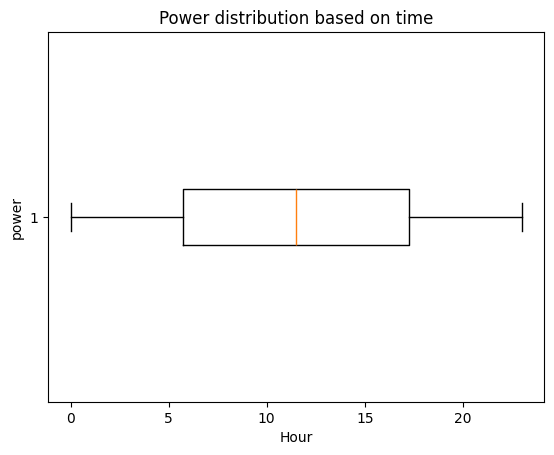

In [15]:
df['Hour'] = pd.to_datetime(df['LocalTime']).dt.hour

plt.boxplot(df['Hour'], vert=False)
plt.ylabel('power')
plt.xlabel('Hour')
plt.title('Power distribution based on time')
plt.show()

In [5]:
# Builds plant_locations.csv
import re
rows = []
for f in files:
    name = f.split('\\')[-1] if '\\' in f else f.split('/')[-1]
    lat, lon = re.findall(r'Actual_(-?\d+\.\d+)_(-?\d+\.\d+)', name)[0]
    rows.append({'plant': name[:30], 'lat': float(lat), 'lon': float(lon)})
pd.DataFrame(rows).to_csv('data/raw/plant_locations.csv', index=False)
print('Saved', len(rows), 'plant locations')

Saved 20 plant locations


In [6]:
import pandas as pd
print(pd.read_csv('data/raw/plant_locations.csv').to_string())

                             plant    lat     lon
0   Actual_33.65_-117.25_2006_DPV_  33.65 -117.25
1   Actual_34.55_-118.55_2006_UPV_  34.55 -118.55
2   Actual_38.65_-121.05_2006_DPV_  38.65 -121.05
3   Actual_33.05_-116.85_2006_DPV_  33.05 -116.85
4   Actual_33.25_-114.85_2006_UPV_  33.25 -114.85
5   Actual_33.75_-116.15_2006_UPV_  33.75 -116.15
6   Actual_34.05_-117.15_2006_DPV_  34.05 -117.15
7   Actual_37.45_-121.95_2006_DPV_  37.45 -121.95
8   Actual_37.95_-121.65_2006_DPV_  37.95 -121.65
9   Actual_35.05_-118.15_2006_UPV_  35.05 -118.15
10  Actual_37.95_-121.75_2006_DPV_  37.95 -121.75
11  Actual_33.75_-116.25_2006_DPV_  33.75 -116.25
12  Actual_35.35_-117.85_2006_UPV_  35.35 -117.85
13  Actual_38.65_-121.25_2006_DPV_  38.65 -121.25
14  Actual_34.15_-117.25_2006_DPV_  34.15 -117.25
15  Actual_34.95_-118.25_2006_UPV_  34.95 -118.25
16  Actual_34.25_-117.65_2006_UPV_  34.25 -117.65
17  Actual_37.75_-122.05_2006_UPV_  37.75 -122.05
18  Actual_32.75_-115.45_2006_UPV_  32.75 -115.45


In [7]:
import glob, pandas as pd

files = sorted(glob.glob('data/raw/nsrdb_downloads/*.csv'))
plants = pd.read_csv('data/raw/plant_locations.csv')

all_data, sites = [], []
for i, f in enumerate(files):
    meta = pd.read_csv(f, nrows=1)              # first row = metadata (lat, lon, etc.)
    d = pd.read_csv(f, skiprows=2)               # actual data starts after 2 header rows
    d['site_id'] = i
    d['ts'] = pd.to_datetime(d[['Year','Month','Day','Hour']])
    d = d.rename(columns={'Cloud Type':'cloud', 'Temperature':'temp'})
    all_data.append(d[['site_id','ts','GHI','DNI','cloud','temp']])
    sites.append({'site_id': i, 'lat': meta['Latitude'][0], 'lon': meta['Longitude'][0]})

pd.concat(all_data).to_csv('data/raw/nsrdb_ca_2006.csv', index=False)
pd.DataFrame(sites).to_csv('data/raw/nsrdb_sites.csv', index=False)
print('Combined', len(files), 'sites into nsrdb_ca_2006.csv')

Combined 20 sites into nsrdb_ca_2006.csv


## Step 2: understand the data, clean it, and merge in a second source

**What to do**: standardize column names; drop duplicates by key; drop missing values in the target variable; remove values outside the physically valid range per agency documentation; build a complete time key and interpolate short gaps; merge in the second data source; save to parquet.

**Check**: row count after the merge doesn't increase; match rate above 90%; log the number of rows dropped at each step in the cleaning log (next cell).

In [8]:
# Step 2: drop night hours, merge NSRDB (GHI, DNI, cloud) by nearest coordinates
nsr = pd.read_csv('data/raw/nsrdb_ca_2006.csv', parse_dates=['ts'])    # columns: site_id, ts, GHI, DNI, cloud, temp
loc = pd.read_csv('data/raw/plant_locations.csv')                      # plant, lat, lon
nsr_loc = pd.read_csv('data/raw/nsrdb_sites.csv')                      # site_id, lat, lon
from sklearn.neighbors import BallTree; import numpy as np
tree = BallTree(np.radians(nsr_loc[['lat', 'lon']]), metric='haversine')
_, i = tree.query(np.radians(loc[['lat', 'lon']]), k=1); loc['site_id'] = nsr_loc.site_id.values[i[:, 0]]
m = (df.merge(loc[['plant', 'site_id']], on='plant').merge(cap, on='plant')
       .merge(nsr, left_on=['site_id', 'LocalTime'], right_on=['site_id', 'ts'], how='left'))
m = m[m.GHI > 0].dropna(subset=['power']); m['cf'] = m.power / m.cap_mw
print('share with irradiance:', m.GHI.notna().mean().round(3)); m.to_parquet('data/processed/solar.parquet', index=False)

share with irradiance: 1.0


In [9]:
# Check that row count after the merge doesn't increase
print('df rows:', len(df))
print('m rows (before GHI/power filter):', len(df.merge(loc[['plant','site_id']], on='plant').merge(cap, on='plant').merge(nsr, left_on=['site_id','LocalTime'], right_on=['site_id','ts'], how='left')))

df rows: 175200
m rows (before GHI/power filter): 175200


### 2.1. Cleaning log (table to include in the paper)

For each step: step name, rows before, rows after, rows dropped, documented reason.

In [10]:
# Re-run the cleaning steps as functions so each one is logged (keep the same order as the cell above)
def clean_log(df0, steps):
    rows, d = [], df0.copy()
    for name, fn, why in steps:
        n0 = len(d); d = fn(d); rows.append([name, n0, len(d), n0 - len(d), why])
    return d, pd.DataFrame(rows, columns=['step', 'rows_before', 'rows_after', 'dropped', 'reason'])
_, cleaning_log = clean_log(m, [
    ('drop duplicates', lambda x: x.drop_duplicates(['plant', 'ts']), 'same unit and timestamp'),
    ('drop missing target', lambda x: x.dropna(subset=['cf']), 'cannot be forecast'),
])
cleaning_log.to_csv('report/table_cleaning_log.csv', index=False); print(cleaning_log)

                  step  rows_before  rows_after  dropped                   reason
0      drop duplicates        87302       87302        0  same unit and timestamp
1  drop missing target        87302       87302        0       cannot be forecast


### 1.2. EDA part 1: table structure (info, describe) and how to read it

**What to do**: `info()` shows the data type and non-missing cell count of each column; `describe()` gives the five-number summary and mean; for categorical columns, look at the number of distinct values and the most frequent value.

**How to read it**: a numeric column with `dtype` object means it has stray characters that need type coercion; an unusual `max` (e.g. 999, -9999) is the agency's missing-value code; `std` equal to 0 means a constant column, drop it. Record these findings in the `report/table_eda_notes.csv` table to include in the paper's Data section.

In [11]:
eda = m.copy()
import io
buf = io.StringIO(); eda.info(buf=buf); print(buf.getvalue()[:3000])
desc_num = eda.describe().T                         # numeric statistics
desc_num['skew'] = eda.select_dtypes('number').skew()  # skewness, > 1 means strongly right-skewed
desc_num.round(3).to_csv('report/table_describe_numeric.csv'); print(desc_num.round(3).head(15))
desc_cat = eda.select_dtypes(exclude='number').describe().T   # categorical columns: count, unique, top, freq
desc_cat.to_csv('report/table_describe_categorical.csv'); print(desc_cat.head(15))
notes = []                                          # record EDA notes for the paper
for c in eda.select_dtypes('number').columns:
    s = eda[c]
    if s.std() == 0: notes.append([c, 'constant column, drop'])
    if s.max() in (999, 9999, 99999, -9999): notes.append([c, 'agency missing code, replace with NaN'])
    if abs(s.skew()) > 2: notes.append([c, 'strongly skewed, consider log or tree models'])
pd.DataFrame(notes, columns=['column', 'note']).to_csv('report/table_eda_notes.csv', index=False); print(notes)

<class 'pandas.core.frame.DataFrame'>
Index: 87302 entries, 7 to 175193
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   LocalTime  87302 non-null  datetime64[ns]
 1   power      87302 non-null  float64       
 2   plant      87302 non-null  object        
 3   site_id    87302 non-null  int64         
 4   cap_mw     87302 non-null  float64       
 5   ts         87302 non-null  datetime64[ns]
 6   GHI        87302 non-null  int64         
 7   DNI        87302 non-null  int64         
 8   cloud      87302 non-null  int64         
 9   temp       87302 non-null  float64       
 10  cf         87302 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(4), object(1)
memory usage: 8.0+ MB

             count                           mean                  min                  25%                  50%                  75%                  max  \
LocalTime    87302  2006-06-30 17:47:38.2437

### 1.3. EDA part 2: missing data, missingness patterns, and handling decisions

**How to look**: missing rate per column; missingness over time (are any months entirely missing?); missingness by unit (plant, panel, state); do columns go missing together (co-missingness matrix)?

**Handling decisions** (record in the table and in the paper):
- Missing **target variable**: drop the row, never impute.
- **Short** gaps in the time series (1-3 steps): linear interpolation per unit.
- **Long** gaps or a whole month missing: drop that segment for that unit, record the reason.
- Column missing over 40%: drop the column or keep only a present/absent flag.
- Missing categorical column: group into an `unknown` class.
- For tree models (LightGBM, XGBoost), missing feature values can be left as-is — the model handles them; for ridge, they must be imputed (median) after the train/test split.

In [12]:
miss = eda.isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
miss['decision'] = np.select([miss.missing_rate == 0, miss.missing_rate < 0.05, miss.missing_rate < 0.4],
                             ['keep', 'interpolate/impute median', 'drop or keep flag'], 'drop column')
miss.round(4).to_csv('report/table_missing.csv'); print(miss.head(15))
# missingness of the target by time and by unit
tcol, gcol = 'ts', 'plant'
by_time = eda.groupby(pd.to_datetime(eda[tcol], errors='coerce').dt.to_period('M') if not np.issubdtype(eda[tcol].dtype, np.number) else eda[tcol])['cf'].apply(lambda s: s.isna().mean())
by_unit = eda.groupby(gcol)['cf'].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
print('target missing by period (top):', by_time.sort_values(ascending=False).head(5).round(3).to_dict())
print('target missing by unit (top):', by_unit.head(5).round(3).to_dict())
# co-missingness matrix: do columns go missing together
co = eda.isna().astype(int); co = co.loc[:, co.sum() > 0]
if co.shape[1] > 1: print(co.corr().round(2))
fig, ax = plt.subplots(figsize=(7, 3))
miss.missing_rate.head(12).plot.bar(ax=ax, color='#1B6B6D'); ax.set_ylabel('Missing rate'); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); fig.savefig('report/fig_eda_missing.png', dpi=300)

           missing_rate decision
LocalTime           0.0     keep
power               0.0     keep
plant               0.0     keep
site_id             0.0     keep
cap_mw              0.0     keep
ts                  0.0     keep
GHI                 0.0     keep
DNI                 0.0     keep
cloud               0.0     keep
temp                0.0     keep
cf                  0.0     keep
target missing by period (top): {Period('2006-01', 'M'): 0.0, Period('2006-02', 'M'): 0.0, Period('2006-03', 'M'): 0.0, Period('2006-04', 'M'): 0.0, Period('2006-05', 'M'): 0.0}
target missing by unit (top): {'Actual_32.75_-115.45_2006_UPV_': 0.0, 'Actual_33.05_-116.85_2006_DPV_': 0.0, 'Actual_33.25_-114.85_2006_UPV_': 0.0, 'Actual_33.65_-117.25_2006_DPV_': 0.0, 'Actual_33.75_-116.15_2006_UPV_': 0.0}


### 1.4. EDA part 3: column selection and grouped, time-based statistics

**Column selection** based on three criteria: (1) has physical or business meaning relative to the target; (2) available at forecast time (not a future value); (3) not duplicated with another column (correlation above 0.95 → keep only one). The `table_columns.csv` table records which columns are kept, which are dropped, and why; this table is part of the Data section of the paper.

**Statistics**: mean, median, 5th and 95th percentile of the target by group and by period; this is the first table answering RQ1, before doing SQL.

In [13]:
num_cols = [c for c in ['cf', 'GHI', 'DNI', 'cloud', 'temp'] if c in eda.columns]
corr = eda[num_cols].corr()
corr.round(3).to_csv('report/table_corr.csv'); print(corr.round(3))
cols = []
for c in eda.columns:
    if c == 'cf': cols.append([c, 'target', 'keep']); continue
    if c in ('ts', 'plant'): cols.append([c, 'time/unit key', 'keep for feature building']); continue
    if c in num_cols:
        r = corr.loc[c, 'cf'] if 'cf' in corr.columns else np.nan
        cols.append([c, f'correlation with target {r:.2f}', 'keep' if abs(r) > 0.05 or np.isnan(r) else 'consider dropping'])
    else: cols.append([c, 'other', 'review'])
pd.DataFrame(cols, columns=['column', 'reason', 'decision']).to_csv('report/table_columns.csv', index=False)
# target statistics by unit and by period
q = lambda s: pd.Series({'mean': s.mean(), 'median': s.median(), 'p05': s.quantile(0.05), 'p95': s.quantile(0.95), 'n': s.count()})
by_g = eda.groupby('plant')['cf'].apply(q).unstack().sort_values('mean', ascending=False)
by_g.round(3).to_csv('report/table_target_by_unit.csv'); print(by_g.head(10).round(3))
period = eda['ts'] if np.issubdtype(eda['ts'].dtype, np.number) else pd.to_datetime(eda['ts'], errors='coerce').dt.month
by_t = eda.groupby(period)['cf'].apply(q).unstack()
by_t.round(3).to_csv('report/table_target_by_period.csv'); print(by_t.round(3))

          cf    GHI    DNI  cloud   temp
cf     1.000  0.840  0.680 -0.268  0.355
GHI    0.840  1.000  0.765 -0.317  0.533
DNI    0.680  0.765  1.000 -0.670  0.392
cloud -0.268 -0.317 -0.670  1.000 -0.229
temp   0.355  0.533  0.392 -0.229  1.000
                                 mean  median    p05    p95       n
plant                                                              
Actual_33.75_-116.15_2006_UPV_  0.568   0.662  0.044  0.841  4363.0
Actual_32.75_-115.45_2006_UPV_  0.549   0.651  0.000  0.834  4329.0
Actual_34.95_-118.25_2006_UPV_  0.544   0.632  0.044  0.834  4377.0
Actual_35.05_-118.15_2006_UPV_  0.538   0.627  0.041  0.822  4377.0
Actual_37.75_-122.05_2006_UPV_  0.471   0.506  0.010  0.861  4376.0
Actual_33.25_-114.85_2006_UPV_  0.466   0.523  0.000  0.856  4329.0
Actual_33.75_-116.25_2006_DPV_  0.455   0.502  0.001  0.839  4363.0
Actual_33.05_-116.85_2006_DPV_  0.439   0.451  0.001  0.863  4375.0
Actual_34.45_-114.65_2006_UPV_  0.430   0.472  0.000  0.797  4329.0
Actual

## Step 3: SQL analysis, answering RQ1 and building features

**What to do**: load the parquet into DuckDB; Q1 and Q2 aggregate to answer RQ1 (GROUP BY, window functions, CTE); Q3 builds lag features, rolling averages, and future targets using LAG, LEAD, AVG OVER; Q4 checks data quality. Save everything to `sql/queries.sql`; each SELECT query is saved as `report/table_q*.csv`.

**Check**: pick one unit and 10 rows, compute the rolling average by hand and compare with SQL; no feature may use a value from after the forecast time point.

In [14]:
# SQL statements run one by one in DuckDB; each SELECT prints its first 20 rows and is saved to report/table_q{k}.csv
import duckdb
if 'con' not in globals(): con = duckdb.connect('data/processed/ady.duckdb')   # reuse the connection opened in Step 1
SQL = r"""
-- Step 3: sql/queries.sql
CREATE OR REPLACE TABLE sol AS SELECT * FROM 'data/processed/solar.parquet';
-- Q1: capacity factor by hour and month per plant
SELECT plant, hour(ts) AS hr, month(ts) AS mon, AVG(cf) AS cf FROM sol GROUP BY 1, 2, 3;
-- Q2: variability by cloud group
SELECT CASE WHEN cloud < 20 THEN 'clear' WHEN cloud < 70 THEN 'partly' ELSE 'overcast' END AS sky,
       corr(power, GHI) AS corr_ghi, STDDEV(cf) AS sd_cf, COUNT(*) AS n
FROM sol GROUP BY 1;
-- Q3: features and targets 1 and 6 hours ahead
CREATE OR REPLACE TABLE feat AS
SELECT plant, ts, cf, GHI, DNI, cloud, temp, hour(ts) AS hr, month(ts) AS mon,
       LAG(cf, 1) OVER w AS cf_lag1, LAG(cf, 24) OVER w AS cf_lag24,
       AVG(cf) OVER (w ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS cf_ma3,
       LEAD(cf, 1) OVER w AS y_1h, LEAD(cf, 6) OVER w AS y_6h
FROM sol WINDOW w AS (PARTITION BY plant ORDER BY ts);
SELECT COUNT(*) AS n, COUNT(y_6h) AS n6 FROM feat;
"""
k = 0
for stmt in SQL.split(';'):
    stmt = '\n'.join(l for l in stmt.splitlines() if not l.strip().startswith('--')).strip()
    if not stmt: continue
    res = con.execute(stmt)
    if stmt.upper().startswith(('SELECT', 'WITH')):
        k += 1; out = res.df(); out.to_csv(f'report/table_q{k}.csv', index=False); print(f'--- Q{k} ---'); print(out.head(20))
open('sql/queries.sql', 'w').write(SQL)

--- Q1 ---
                             plant  hr  mon        cf
0   Actual_35.05_-118.15_2006_UPV_  11   11  0.672173
1   Actual_35.05_-118.15_2006_UPV_  10   12  0.588647
2   Actual_37.95_-121.75_2006_DPV_   9    3  0.439239
3   Actual_37.95_-121.75_2006_DPV_   6    4  0.039444
4   Actual_37.95_-121.75_2006_DPV_  11    5  0.766907
5   Actual_37.95_-121.75_2006_DPV_  12    5  0.760725
6   Actual_37.95_-121.75_2006_DPV_  16    5  0.325380
7   Actual_37.95_-121.75_2006_DPV_  17    5  0.135342
8   Actual_33.65_-117.25_2006_DPV_   7    2  0.110338
9   Actual_33.65_-117.25_2006_DPV_   6    4  0.080000
10  Actual_33.65_-117.25_2006_DPV_  12    5  0.719225
11  Actual_33.65_-117.25_2006_DPV_   5    6  0.007420
12  Actual_33.65_-117.25_2006_DPV_  14    8  0.655148
13  Actual_33.65_-117.25_2006_DPV_  12    9  0.792332
14  Actual_33.65_-117.25_2006_DPV_   8   11  0.381166
15  Actual_33.65_-117.25_2006_DPV_  15   12  0.220703
16  Actual_34.55_-118.55_2006_UPV_  10    2  0.612507
17  Actual_34.55_

943

### 3.2. Continuing from SQL: tables answering RQ1 with pandas and statistical tests

**What to do**: from the Q1, Q2 results, build numbered tables to drop straight into the paper; test the difference between groups (Kruskal-Wallis, no normality assumption needed) and Spearman correlation between the target and exogenous variables, with p-values.

**How to read it**: p < 0.05 means the difference between groups is unlikely due to chance; the Spearman coefficient gives the direction and strength of the monotonic relationship; the RQ1 conclusion must be a sentence with a number, e.g. "winter is 1.9 times higher than summer, p < 0.001".

In [15]:
from scipy.stats import kruskal, spearmanr
q1 = con.execute("SELECT * FROM feat").df()          # feature table created in Q3
if np.issubdtype(q1['ts'].dtype, np.number): q1['period'] = q1['ts']            # numeric time key (year, cycle)
else: q1['period'] = pd.to_datetime(q1['ts'], errors='coerce').dt.month             # datetime key: use month as period
# Table RQ1a: target by period
rq1a = q1.groupby('period')['cf'].agg(['mean', 'median', 'std', 'count']).round(3)
rq1a.to_csv('report/table_rq1a_period.csv'); print(rq1a)
groups = [s.values for _, s in q1.groupby('period')['cf'] if len(s) > 30]
if len(groups) > 1: print('Kruskal-Wallis across periods:', kruskal(*groups))
# Table RQ1b: Spearman correlation of the target with exogenous variables
ext = [c for c in q1.select_dtypes('number').columns if c not in ('cf', 'y_1h') and not c.startswith('cf')]
rows = []
for c in ext[:15]:
    r, pv = spearmanr(q1[c], q1['cf'], nan_policy='omit'); rows.append([c, round(r, 3), pv])
rq1b = pd.DataFrame(rows, columns=['variable', 'spearman_r', 'p_value']).sort_values('spearman_r', key=abs, ascending=False)
rq1b.to_csv('report/table_rq1b_corr.csv', index=False); print(rq1b)
# Table RQ1c: target by unit, top and bottom 5
rq1c = q1.groupby('plant')['cf'].agg(['mean', 'count']).sort_values('mean', ascending=False)
pd.concat([rq1c.head(5), rq1c.tail(5)]).round(3).to_csv('report/table_rq1c_units.csv')
print('RQ1 CONCLUSION (fill with real numbers): highest period', rq1a['mean'].idxmax(), 'is', round(rq1a['mean'].max() / max(rq1a['mean'].min(), 1e-9), 2), 'times the lowest period')

         mean  median    std  count
period                             
1       0.407   0.432  0.267   6152
2       0.444   0.473  0.273   5903
3       0.405   0.395  0.291   7363
4       0.428   0.410  0.300   7665
5       0.470   0.527  0.298   8556
6       0.450   0.503  0.278   8420
7       0.441   0.495  0.280   8688
8       0.470   0.548  0.279   8287
9       0.496   0.571  0.270   7213
10      0.459   0.520  0.268   6820
11      0.407   0.449  0.259   6172
12      0.389   0.428  0.256   6063
Kruskal-Wallis across periods: KruskalResult(statistic=np.float64(1146.1267360922188), pvalue=np.float64(6.579825474097682e-239))
  variable  spearman_r        p_value
0      GHI       0.847   0.000000e+00
1      DNI       0.727   0.000000e+00
6     y_6h      -0.463   0.000000e+00
3     temp       0.357   0.000000e+00
2    cloud      -0.309   0.000000e+00
4       hr      -0.080  7.605458e-125
5      mon       0.009   7.094113e-03
7   period       0.009   7.094113e-03
RQ1 CONCLUSION (fill wit

## Step 5 (part A): a diverse set of figures answering RQ1

Each figure is tied to one point of RQ1 and has a caption stating the conclusion. Figure set: (1) target distribution, histogram and boxplot; (2) time series for a few units; (3) period x unit heatmap; (4) target boxplot by period; (5) scatter of the target against the strongest exogenous variable; (6) correlation heatmap; (7) group comparison with labeled bars. Rules: English text, remove top and right spines, bold numbers on bars, 300 dpi, filenames `fig_rq1_*.png`.

In [16]:
import seaborn as sns
def style(ax): ax.spines[['top', 'right']].set_visible(False)
d = q1.dropna(subset=['cf'])
# (1) distribution
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(d['cf'], bins=50, color='#1B6B6D'); ax[0].set_xlabel('cf capacity factor'); ax[0].set_ylabel('Count'); style(ax[0])
ax[1].boxplot(d['cf'], vert=False); ax[1].set_xlabel('cf'); style(ax[1])
fig.tight_layout(); fig.savefig('report/fig_rq1_distribution.png', dpi=300); plt.close(fig)
# (2) time series of the first 3 units
units = d['plant'].unique()[:3]
fig, ax = plt.subplots(figsize=(9, 3))
for u in units:
    s = d[d['plant'] == u].sort_values('ts'); ax.plot(s['ts'], s['cf'], lw=0.8, label=str(u))
ax.set_ylabel('cf'); ax.legend(frameon=False); style(ax); fig.tight_layout(); fig.savefig('report/fig_rq1_timeseries.png', dpi=300); plt.close(fig)
# (3) heatmap period x unit (top 15 units)
top = d.groupby('plant')['cf'].mean().nlargest(15).index
hm = d[d['plant'].isin(top)].pivot_table(index='plant', columns='period', values='cf', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 4)); sns.heatmap(hm, cmap='YlGnBu', ax=ax, cbar_kws={'label': 'cf'}); ax.set_xlabel('Period'); ax.set_ylabel('Unit')
fig.tight_layout(); fig.savefig('report/fig_rq1_heatmap.png', dpi=300); plt.close(fig)
# (4) boxplot by period
fig, ax = plt.subplots(figsize=(9, 3)); sns.boxplot(data=d, x='period', y='cf', color='#9FBFBF', ax=ax, showfliers=False); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq1_box_period.png', dpi=300); plt.close(fig)
# (5) scatter against the strongest exogenous variable
if len(rq1b):
    v = rq1b.iloc[0].variable
    fig, ax = plt.subplots(figsize=(5, 3.5)); ax.scatter(d[v], d['cf'], s=4, alpha=0.3, color='#1B6B6D'); ax.set_xlabel(v); ax.set_ylabel('cf'); style(ax)
    fig.tight_layout(); fig.savefig('report/fig_rq1_scatter.png', dpi=300); plt.close(fig)
# (6) correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5)); sns.heatmap(d.select_dtypes('number').corr().round(2), cmap='coolwarm', center=0, ax=ax, annot=False)
fig.tight_layout(); fig.savefig('report/fig_rq1_corr.png', dpi=300); plt.close(fig)
# (7) group comparison with labelled bars
gm = d.groupby('period')['cf'].mean()
fig, ax = plt.subplots(figsize=(8, 3)); bars = ax.bar(gm.index.astype(str), gm.values, color='#1B6B6D'); ax.bar_label(bars, fmt='%.1f', fontweight='bold', fontsize=8); ax.set_ylabel('Mean cf'); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq1_period_bar.png', dpi=300); plt.close(fig)
print('7 figures saved to report/. Write each caption as: conclusion + number + condition.')

7 figures saved to report/. Write each caption as: conclusion + number + condition.


## Test cases for Notebook_A (run before handoff)

Each assert is a condition that must hold; if it fails, fix the corresponding step and rerun. Once all pass, the last cell creates `manifest.json` for Student B to check.

In [17]:
import hashlib, json, os
feat = con.execute("SELECT * FROM feat").df()
assert len(feat) >= 30000, 'fewer than 30k rows, widen the scope'
assert feat['y_1h'].notna().sum() > 0.8 * len(feat), 'too many missing targets'
key = ['plant', 'ts']
assert not feat.duplicated(key).any(), 'duplicate unit-time keys'
lead_cols = [c for c in feat.columns if c.startswith('y_') and c != 'y_1h']
assert all(c.startswith('y_') for c in lead_cols), 'only target columns may contain future values'
print('Tests A: OK')
feat.to_parquet('data/processed/feat.parquet', index=False)
h = hashlib.md5(open('data/processed/feat.parquet', 'rb').read()).hexdigest()
manifest = {'rows': int(len(feat)), 'cols': list(feat.columns), 'md5': h,
            'time_min': str(feat['ts'].min()), 'time_max': str(feat['ts'].max()), 'author': 'Student A'}
json.dump(manifest, open('data/processed/manifest.json', 'w'), indent=2, default=str); print(manifest)

Tests A: OK
{'rows': 87302, 'cols': ['plant', 'ts', 'cf', 'GHI', 'DNI', 'cloud', 'temp', 'hr', 'mon', 'cf_lag1', 'cf_lag24', 'cf_ma3', 'y_1h', 'y_6h'], 'md5': '8dfe447813c6cb633dfcb503df1abdd2', 'time_min': '2006-01-01 07:00:00', 'time_max': '2006-12-31 17:00:00', 'author': 'Student A'}


## Common errors and how to fix them (read when you see red text)

| Error | Cause | Fix |
|---|---|---|
| ModuleNotFoundError | library not installed or wrong interpreter selected | rerun pip install from Step 0; Ctrl+Shift+P and select the .venv interpreter |
| FileNotFoundError | path or filename is incorrect | check data/raw with `import os; print(os.listdir('data/raw'))` |
| KeyError: 'column_name' | actual column name differs from the one in the code | print `df.columns`; fix the name in one place (the Step 1 cell) and rerun |
| MemoryError or the machine hangs | loading an oversized file entirely into pandas | filter with WHERE in DuckDB first; read parquet instead of CSV; reduce the year range |
| UnicodeDecodeError | the CSV file is encoded differently from UTF-8 | add `encoding='latin1'` or let DuckDB's read_csv_auto guess it |
| ValueError: could not convert | a numeric column has stray characters or missing-value codes | `pd.to_numeric(col, errors='coerce')` then check the missingness table |
| Merge increased the row count | the merge key has duplicates in the secondary table | `drop_duplicates` on the key in the secondary table before merging |
| Suspiciously good results (MAE near 0) | target leakage into the features | check that X_cols doesn't contain any y_* columns; split by time |
| Results differ each run | seed not fixed | set random_state, np.random.seed(42) |

Principle: read the last line of the error message first; fix one thing and rerun from that cell; if not resolved after 30 minutes, screenshot the error and ask for help.

## Checklist before reporting (mark [x] once the evidence file exists)

- [ ] requirements.txt, README.md, .gitignore, GitHub repo with commits this week
- [ ] Data matches the correct agency file, over 30 thousand rows: table_describe_raw.csv, profile.html
- [ ] EDA: table_describe_numeric.csv, table_describe_categorical.csv, table_eda_notes.csv, table_missing.csv, table_columns.csv, table_target_by_unit.csv, table_target_by_period.csv
- [ ] Cleaning: table_cleaning_log.csv; second data source merged with over 90% match
- [ ] SQL: sql/queries.sql, table_q1..q4.csv; RQ1: table_rq1a_period.csv, table_rq1b_corr.csv, table_rq1c_units.csv with p-values
- [ ] 7 RQ1 figures in report/ with captions that are conclusion sentences containing numbers
- [ ] Test cases pass; manifest.json handed off; the other person has rerun it and logged the cross-check
- [ ] (Notebook_B) table_features.csv, table_rq2.csv, 4 RQ2 figures, table_tuning.csv, table_rq3_*.csv, table_shap.csv, table_diagnosis.csv, params_best.json
- [ ] Personal Audit Log has all of this week's prompts
- [ ] The five-item report has been posted to the group channel before 7:00 on Tuesday or Friday

## Progress report template (slot 1, Tuesday and Friday, 7:00 to 9:15)

Post to the group channel before 7:00 on the report day, one part per person. Five items, two to three lines each:

1. **Completed** since last time: file name, row count, table count, figure count (e.g.: `feat.parquet` 138,204 rows; 4 RQ1 tables; 7 figures).
2. **New key numbers**: e.g. naive MAE 6.8; LightGBM MAE 4.7 (5 seeds, sd 0.1).
3. **Blockers and what was tried**: the specific error, a screenshot, two approaches already attempted.
4. **What's next, who's doing it**: per Table 13 of the proposal.
5. **Notable AI prompt and Human Delta**: one prompt, what AI answered, what I checked or fixed.

**Cross-check**: the other person reruns this notebook on their own machine and records the row count and metrics they got here: ...............................